In [3]:
pip install librosa 


  Using cached librosa-0.11.0-py3-none-any.whl.metadata (8.7 kB)
  Using cached audioread-3.1.0-py3-none-any.whl.metadata (9.0 kB)
  Using cached soundfile-0.13.1-py2.py3-none-win_amd64.whl.metadata (16 kB)
  Using cached pooch-1.9.0-py3-none-any.whl.metadata (10 kB)
Using cached librosa-0.11.0-py3-none-any.whl (260 kB)
Using cached audioread-3.1.0-py3-none-any.whl (23 kB)
Using cached pooch-1.9.0-py3-none-any.whl (67 kB)
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 1.0/1.0 MB 12.2 MB/s eta 0:00:00


[-0.10539334 -0.1816167  -0.17428888 ... -0.336831   -0.3227148
 -0.31628376]
22050


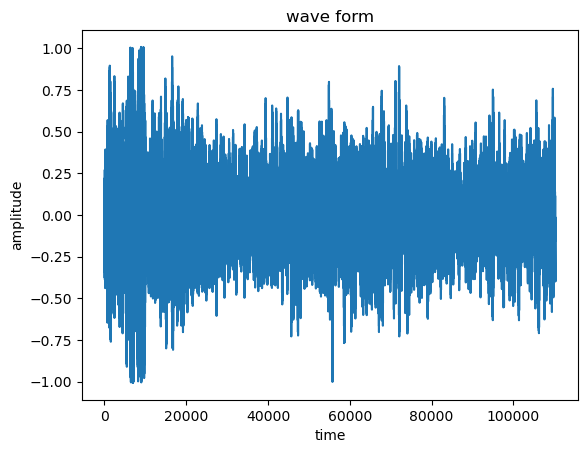

In [15]:
#here sr is the sampling rate 
import librosa 

#here we will add only a single file path of one audio file 
file_path = "audio\\1-31482-B-42.wav"

#now we will load the audio using librosa 
audio, sr = librosa.load(file_path)

print(audio)
print(sr)

plt.plot(audio)
plt.title("wave form")
plt.xlabel("time")
plt.ylabel("amplitude")
plt.show()

Here in tha above graph the big spikes are the loud sounds and the samll spikes are the quiet sounds

In [18]:
#now we will be generating mfcc of the above sound 
mfcc = librosa.feature.mfcc(
    y = audio,
    sr = sr,
    n_mfcc = 40
)

print(mfcc.shape)

(40, 216)


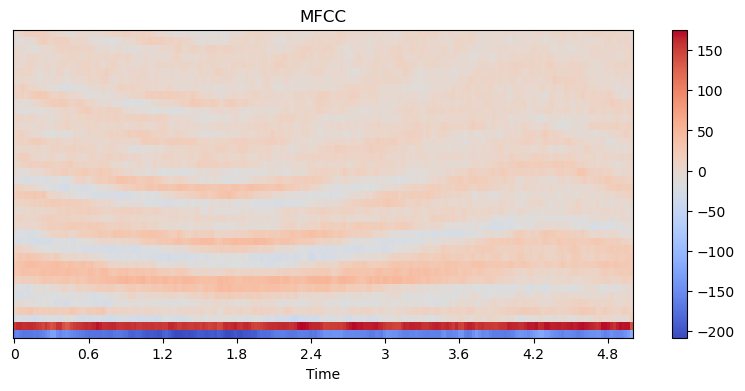

In [19]:
#we will now display mfcc as a image 
plt.figure(figsize=(10,4))

librosa.display.specshow(
    mfcc,
    x_axis = "time"
)

plt.colorbar()
plt.title("MFCC")
plt.show()

In [20]:
#now we will be filtering out only the important sound class 
import pandas as pd 

#loading the csv 
data = pd.read_csv("meta/esc50.csv")

#this is will show the first rows 
print(data.head())

            filename  fold  target        category  esc10  src_file take
0   1-100032-A-0.wav     1       0             dog   True    100032    A
1  1-100038-A-14.wav     1      14  chirping_birds  False    100038    A
2  1-100210-A-36.wav     1      36  vacuum_cleaner  False    100210    A
3  1-100210-B-36.wav     1      36  vacuum_cleaner  False    100210    B
4  1-101296-A-19.wav     1      19    thunderstorm  False    101296    A


In [21]:
target_classes = [ 
    "siren",
    "crying_baby",
    "glass_breaking",
    "door_wood_knock"
]

In [22]:
filtered_data = data[data["category"].isin(target_classes)]

print(filtered_data.head())

             filename  fold  target         category  esc10  src_file take
6   1-101336-A-30.wav     1      30  door_wood_knock  False    101336    A
9   1-103995-A-30.wav     1      30  door_wood_knock  False    103995    A
10  1-103999-A-30.wav     1      30  door_wood_knock  False    103999    A
78  1-187207-A-20.wav     1      20      crying_baby   True    187207    A
95   1-20133-A-39.wav     1      39   glass_breaking  False     20133    A


In [ ]:
print(filtered_data["filename"])

file_name = filtered_data.iloc[0]["filename"]
print("file name:", file_name)



6       1-101336-A-30.wav
9       1-103995-A-30.wav
10      1-103999-A-30.wav
78      1-187207-A-20.wav
95       1-20133-A-39.wav
              ...        
1969    5-256512-A-30.wav
1971    5-257642-A-39.wav
1979    5-260432-A-39.wav
1980    5-260433-A-39.wav
1981    5-260434-A-39.wav
Name: filename, Length: 160, dtype: object
file name: 1-101336-A-30.wav


4


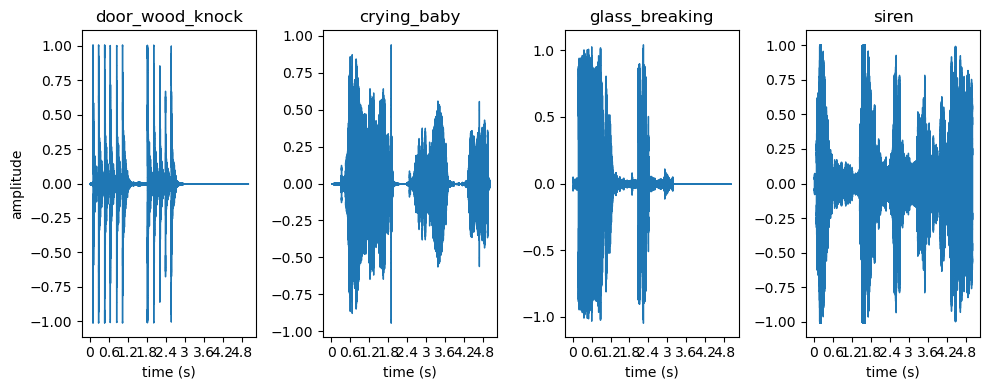

In [43]:
x = [] #for mfcc value 
y = [] #for label

#creating label map 
label_map = { 
    "siren": 0, 
    "crying_baby": 1, 
    "glass_breaking": 2,
    "door_wood_knock": 3
}

unique_plot = {}

#loop through each row 
for index, row in filtered_data.iterrows(): 

    file_name = row["filename"]
    
    label = row["category"]

    file_path = "audio/" + file_name 

    #load the audio 
    audio, sr = librosa.load(file_path)

    #generating mfcc 
    mfcc = librosa.feature.mfcc(
        y = audio, 
        sr = sr,
        n_mfcc = 40
    )

    #storing the mfcc
    x.append(mfcc)

    #storing the label 
    y.append(label_map[label])

    if label not in unique_plot: 
        unique_plot[label] = (audio,sr)

num_plots = len(unique_plot)
print(num_plots)

plt.figure(figsize=(10,4))

for i, (label, (audio_data, sample_rate)) in enumerate(unique_plot.items()): 

    plt.subplot(1, num_plots, i+1)

    librosa.display.waveshow(audio_data, sr = sample_rate)

    plt.title(label)
    plt.xlabel("time (s)")

    if i==0:
        plt.ylabel("amplitude")

plt.tight_layout()
plt.show()


In [34]:
print(len(x))
print(len(y))

160
160


In [45]:
import numpy as np 
from sklearn.model_selection import train_test_split

In [47]:
X_array = np.array(x)
Y_array = np.array(y)

X_cnn = X_array.reshape(-1, X_array.shape[1], X_array.shape[2], 1)

print("shape for tensorflow requierment:", X_cnn.shape)


shape for tensorflow requierment: (160, 40, 216, 1)


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X_cnn,
    Y_array,
    test_size = 0.2, 
    random_state = 42, 
    stratify = Y_array
) 

print(X_train.shape)
print(X_test.shape)

(128, 40, 216, 1)
(32, 40, 216, 1)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Initialize a sequential model framework
model = models.Sequential([
    
    layers.Input(shape=(40, 216, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)), 
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3), 
    layers.Dense(4, activation='softmax')
])


model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 38, 214, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 19, 107, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 17, 105, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 52, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 26624)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     1,704,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,723,076 (6.57 MB)

 Trainable params: 1,723,076 (6.57 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',                        
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']                    
)

In [57]:
# Train the model for 20 rounds (epochs)
history = model.fit(
    X_train, Y_train, 
    epochs=50, 
    batch_size=32, 
    validation_data=(X_test, Y_test)
)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.2365 - loss: 41.1374 - val_accuracy: 0.4375 - val_loss: 8.7653
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.4677 - loss: 6.4383 - val_accuracy: 0.5000 - val_loss: 1.7025
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.4896 - loss: 2.7115 - val_accuracy: 0.6875 - val_loss: 0.8077
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5688 - loss: 1.0988 - val_accuracy: 0.7812 - val_loss: 0.5241
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.7917 - loss: 0.5148 - val_accuracy: 0.7812 - val_loss: 0.5094
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9042 - loss: 0.3748 - val_accuracy: 0.9375 - val_loss: 0.3759
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9146 - loss: 0.3267 - val_accuracy: 0.9375 - val_loss: 0.2341
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9427 - loss: 0.1667 - val_accuracy: 0.9688 - val_loss: 0.1522

In [60]:
model.save("sound_classifier_model.keras")
print("model saved")

model saved


Note: you may need to restart the kernel to use updated packages.
